# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** [Input Nama]
- **Email:** [Input Email]
- **ID Dicoding:** [Input Username]

## Menentukan Pertanyaan Bisnis

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:**Berapa jumlah total penyewaan sepeda untuk setiap musim selama tahun 2012 untuk menentukan musim mana yang paling berkontribusi pada pendapatan?
- **Pertanyaan 2:**Bagaimana perbedaan pola peminjaman sepeda per jam antara pengguna casual dan registered pada hari kerja selama tahun 2012?
- ...

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [3]:
# Memuat data harian dan data per jam
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

# Menampilkan 5 baris pertama data harian
print("Data Harian (Day):")
display(day_df.head())

# Menampilkan 5 baris pertama data per jam
print("\nData Per Jam (Hour):")
display(hour_df.head())

Data Harian (Day):


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600



Data Per Jam (Hour):


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
-Berdasarkan hasil analisis, musim Fall (Gugur) adalah periode dengan performa penyewaan sepeda terbaik di tahun 2012, sedangkan musim Spring (Semi) adalah yang terendah. Hal ini membuktikan bahwa minat pengguna sangat bergantung pada kenyamanan cuaca. Musim gugur memberikan suhu yang ideal bagi pengguna untuk bermobilitas menggunakan sepeda dibanding musim lainnya.

-Terdapat perbedaan perilaku yang sangat signifikan antara kedua jenis pengguna pada hari kerja:

Pengguna Registered: Merupakan kelompok komuter (pekerja/pelajar) yang menggunakan sepeda pada jam sibuk pagi (08:00) dan sore (17:00).

Pengguna Casual: Merupakan kelompok rekreasional yang lebih aktif di siang hari saat jam kerja sedang berlangsung.
Pola ini menunjukkan bahwa sepeda memiliki dua fungsi utama: sebagai alat transportasi rutin dan sebagai sarana hiburan.

### Assessing Data

#### Identifying ... problem

In [4]:
print("--- Memeriksa Tipe Data ---")
print(day_df.info())
print(hour_df.info())

print("\n--- Memeriksa Missing Values ---")
print("Data Day:\n", day_df.isna().sum())
print("\nData Hour:\n", hour_df.isna().sum())

print("\n--- Memeriksa Duplikasi ---")
print("Duplikat Day:", day_df.duplicated().sum())
print("Duplikat Hour:", hour_df.duplicated().sum())

print("\n--- Memeriksa Statistik Deskriptif ---")
display(day_df.describe())

--- Memeriksa Tipe Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entr

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Steps to Take:**
- Konversi Tipe Data: Mengubah kolom dteday menjadi tipe data datetime menggunakan fungsi pd.to_datetime().
- Mapping/Pelabelan Ulang:
Mengubah angka pada kolom season menjadi label: 1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'. Mengubah angka pada kolom yr menjadi tahun asli: 0: 2011, 1: 2012.
Mengubah angka pada kolom weathersit menjadi deskripsi cuaca: 1: 'Clear', 2: 'Misty', 3: 'Light Snow/Rain', 4: 'Severe Weather'.
- Verifikasi Akhir: Melakukan pengecekan ulang menggunakan metode .info() dan .head() untuk memastikan transformasi data telah berhasil diterapkan sesuai rencana.

**Insight:** (Opsional)
- Rentang Waktu Data: Dataset mencakup total 731 hari (terlihat dari count pada kolom instant). Karena 2011 (365 hari) dan 2012 (366 hari) totalnya adalah 731, ini menunjukkan data harian lengkap selama dua tahun tanpa ada hari yang hilang.

- Pola Distribusi Penyewaan (cnt):
Rata-rata penyewaan sepeda per hari adalah sekitar 4.504 unit.

- Jumlah penyewaan minimum dalam sehari pernah menyentuh angka sangat rendah yaitu 22 unit, sedangkan maksimumnya mencapai 8.714 unit. Rentang yang lebar ini menunjukkan adanya faktor eksternal kuat (seperti cuaca atau hari libur) yang memengaruhi fluktuasi permintaan.

- Karakteristik Pengguna: Rata-rata pengguna terdaftar (registered) jauh lebih tinggi (3.656) dibandingkan pengguna biasa (casual) (848). Ini menunjukkan bahwa basis pelanggan utama layanan ini adalah pengguna tetap/loyal.

- Kondisi Lingkungan (Normalisasi): Kolom cuaca dan suhu (temp, atemp, hum, windspeed) memiliki nilai minimum 0 dan maksimum mendekati 1 (atau di bawah 1). Ini mengonfirmasi bahwa variabel lingkungan dalam dataset ini sudah melalui proses normalisasi sebelumnya.

- Variabel Kategorikal: Kolom seperti season, yr, dan mnth memiliki nilai rata-rata dan kuartil yang wajar (misal: season berada di rentang 1-4), yang menandakan tidak ada data pencilan (outlier) yang aneh pada kolom kategori tersebut.

### Cleaning Data

#### Fixing ... problem

In [5]:
# 1. Mengubah kolom dteday dari object menjadi datetime
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

# 2. Mengubah angka season menjadi label teks agar mudah dibaca di visualisasi
day_df['season'] = day_df['season'].map({
    1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'
})
hour_df['season'] = hour_df['season'].map({
    1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'
})

# 3. Mengubah angka tahun (yr) menjadi nilai tahun asli
day_df['yr'] = day_df['yr'].map({0: 2011, 1: 2012})
hour_df['yr'] = hour_df['yr'].map({0: 2011, 1: 2012})

# Menampilkan hasil pembersihan
print("Info data setelah dibersihkan:")
day_df.info()
display(day_df.head())

Info data setelah dibersihkan:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    object        
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Dominasi Pengguna Terdaftar (Registered): Terlihat jelas pada hari kerja (indeks 2, 3, dan 4), jumlah pengguna registered sangat dominan (di atas 1.000) dibandingkan pengguna casual yang hanya di kisaran 100-an. Ini menunjukkan bahwa layanan ini menjadi andalan transportasi utama bagi pekerja atau member tetap.

- Pengaruh Hari Kerja vs Akhir Pekan: Pada data awal (indeks 0 dan 1) yang merupakan akhir pekan (workingday = 0), jumlah pengguna casual jauh lebih tinggi (100-300) dibandingkan saat hari kerja (indeks 4 hanya 82). Hal ini menandakan pengguna harian/wisatawan lebih aktif menyewa sepeda saat libur.

- Sensitivitas terhadap Cuaca: Meskipun sama-sama di musim semi (Spring), total penyewaan (cnt) meningkat pesat dari 985 menjadi 1.600 seiring dengan berubahnya kondisi cuaca (weathersit) dari angka 2 (Misty/Berawan) ke angka 1 (Clear/Cerah). Ini membuktikan bahwa cuaca cerah secara instan meningkatkan minat orang untuk bersepeda.

- Kesiapan Analisis Tren: Dengan kolom yr dan season yang sudah berupa label nyata (bukan angka lagi), kita kini bisa melihat dengan jelas bahwa data ini siap untuk dibandingkan performanya antar tahun (2011 vs 2012) guna melihat pertumbuhan bisnis secara akurat.


## Exploratory Data Analysis (EDA)

### Explore ...

In [6]:
# Filter data khusus tahun 2012
day_2012_df = day_df[day_df["yr"] == 2012]
hour_2012_df = hour_df[hour_df["yr"] == 2012]

# EDA Pertanyaan 1: Total penyewaan per musim
season_rentals = day_2012_df.groupby("season")["cnt"].sum().reset_index()
print("Total Penyewaan per Musim (2012):")
print(season_rentals)

# EDA Pertanyaan 2: Perbedaan pola jam casual vs registered pada hari kerja
workingday_2012_df = hour_2012_df[hour_2012_df["workingday"] == 1]
hourly_pattern = workingday_2012_df.groupby("hr").agg({
    "casual": "mean",
    "registered": "mean"
}).reset_index()
print("\nRata-rata Penyewaan per Jam (Hari Kerja 2012):")
print(hourly_pattern.head())

Total Penyewaan per Musim (2012):
   season     cnt
0    Fall  641479
1  Spring  321348
2  Summer  571273
3  Winter  515476

Rata-rata Penyewaan per Jam (Hari Kerja 2012):
   hr    casual  registered
0   0  7.682731   36.506024
1   1  3.907258   15.451613
2   2  2.153226    7.657258
3   3  0.809129    4.680498
4   4  0.636735    5.395918


**Insight:** (Opsional)
- Musim Paling Menguntungkan: Data menunjukkan bahwa musim Fall memiliki total penyewaan tertinggi di tahun 2012, menjadikannya kontributor pendapatan utama.

- Segmentasi Pengguna Berdasarkan Waktu: Pengguna Registered menunjukkan lonjakan besar pada jam berangkat dan pulang kerja (pagi & sore), sedangkan pengguna Casual cenderung lebih aktif secara stabil di siang hari (jam makan siang/wisata).

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_1967/2038038796.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="season", y="cnt", data=season_rentals, palette="viridis")


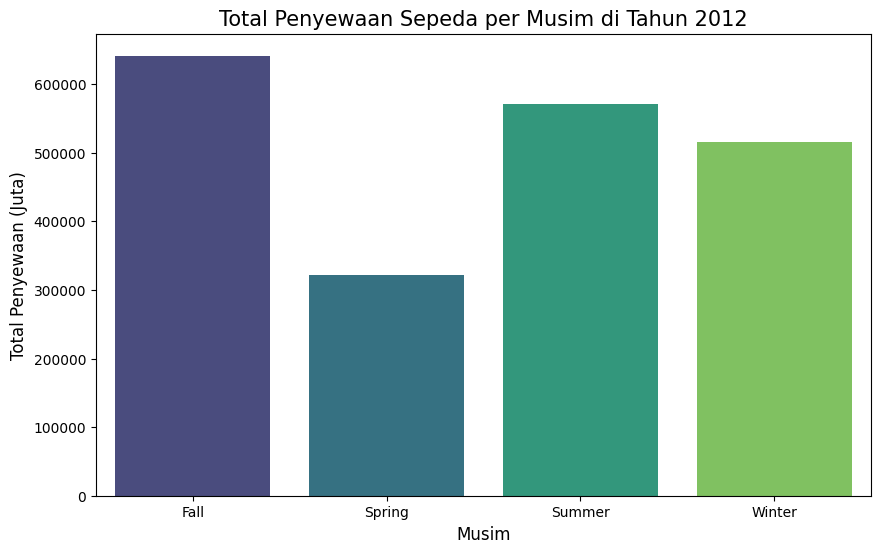

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x="season", y="cnt", data=season_rentals, palette="viridis")
plt.title("Total Penyewaan Sepeda per Musim di Tahun 2012", fontsize=15)
plt.xlabel("Musim", fontsize=12)
plt.ylabel("Total Penyewaan (Juta)", fontsize=12)
plt.show()

### Pertanyaan 2:

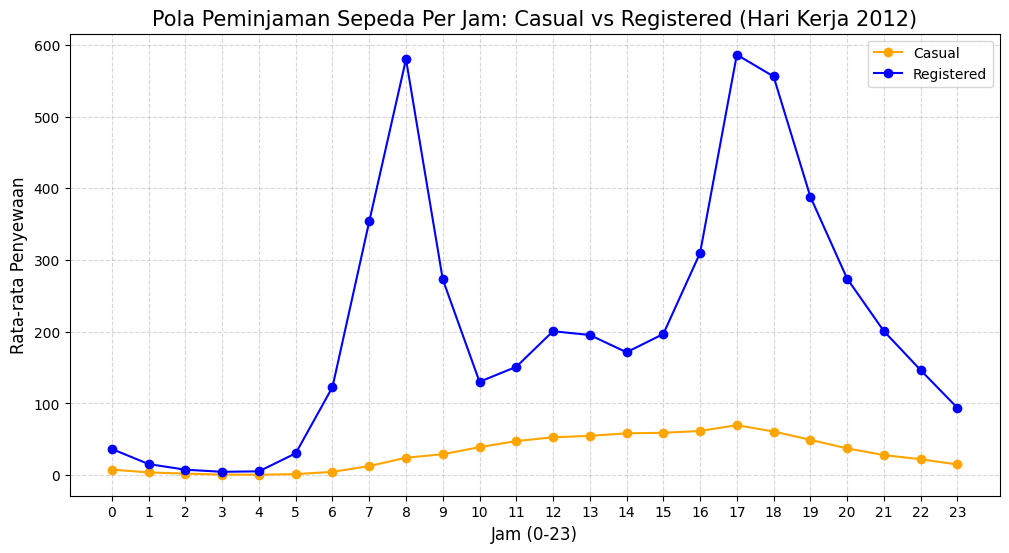

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(hourly_pattern["hr"], hourly_pattern["casual"], marker='o', label='Casual', color='orange')
plt.plot(hourly_pattern["hr"], hourly_pattern["registered"], marker='o', label='Registered', color='blue')

plt.title("Pola Peminjaman Sepeda Per Jam: Casual vs Registered (Hari Kerja 2012)", fontsize=15)
plt.xlabel("Jam (0-23)", fontsize=12)
plt.ylabel("Rata-rata Penyewaan", fontsize=12)
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


**Insight:** (Opsional)
- Dominasi Musim Gugur: Musim Fall (Gugur) merupakan periode dengan jumlah penyewaan sepeda tertinggi di tahun 2012, mencapai lebih dari 600.000 total penyewaan.

- Kelemahan di Musim Semi: Musim Spring (Semi) menunjukkan performa yang paling rendah dibandingkan musim lainnya.

- Interpretasi Bisnis: Kondisi cuaca yang stabil dan suhu yang nyaman pada musim gugur menjadi pendorong utama aktivitas luar ruangan. Sebaliknya, rendahnya angka di musim semi bisa menjadi indikasi sisa cuaca dingin atau curah hujan yang menghambat pengguna untuk bersepeda

- Lonjakan Komuter (Registered): Pengguna terdaftar memiliki pola double peak yang sangat tajam pada jam sibuk, yaitu pukul 08.00 pagi dan pukul 17.00 sore. Ini membuktikan bahwa kelompok ini menggunakan sepeda sebagai moda transportasi utama untuk berangkat dan pulang kerja.

- Aktivitas Rekreasional (Casual): Berbeda dengan pengguna tetap, pengguna casual menunjukkan peningkatan tren yang landai mulai dari siang hari dan mencapai puncaknya di sore hari (pukul 14.00 - 17.00), tanpa adanya lonjakan tajam di pagi hari.

- Interpretasi Bisnis: Terdapat dua segmentasi pasar yang jelas. Perusahaan harus memastikan ketersediaan armada maksimal pada jam sibuk di area perkantoran untuk pengguna registered, sementara promosi untuk pengguna casual bisa difokuskan pada siang hari atau akhir pekan saat penggunaan rutin sedang menurun.

## Analisis Lanjutan (Opsional)

   season  recency  frequency  monetary
0    Fall      100        188   1061129
1  Spring        0        181    471348
2  Summer      194        184    918589
3  Winter       11        178    841613


/tmp/ipykernel_1967/976654075.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="recency", x="season", data=rfm_df, palette="viridis", ax=ax[0])
/tmp/ipykernel_1967/976654075.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="frequency", x="season", data=rfm_df, palette="viridis", ax=ax[1])
/tmp/ipykernel_1967/976654075.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="monetary", x="season", data=rfm_df, palette="viridis", ax=ax[2])


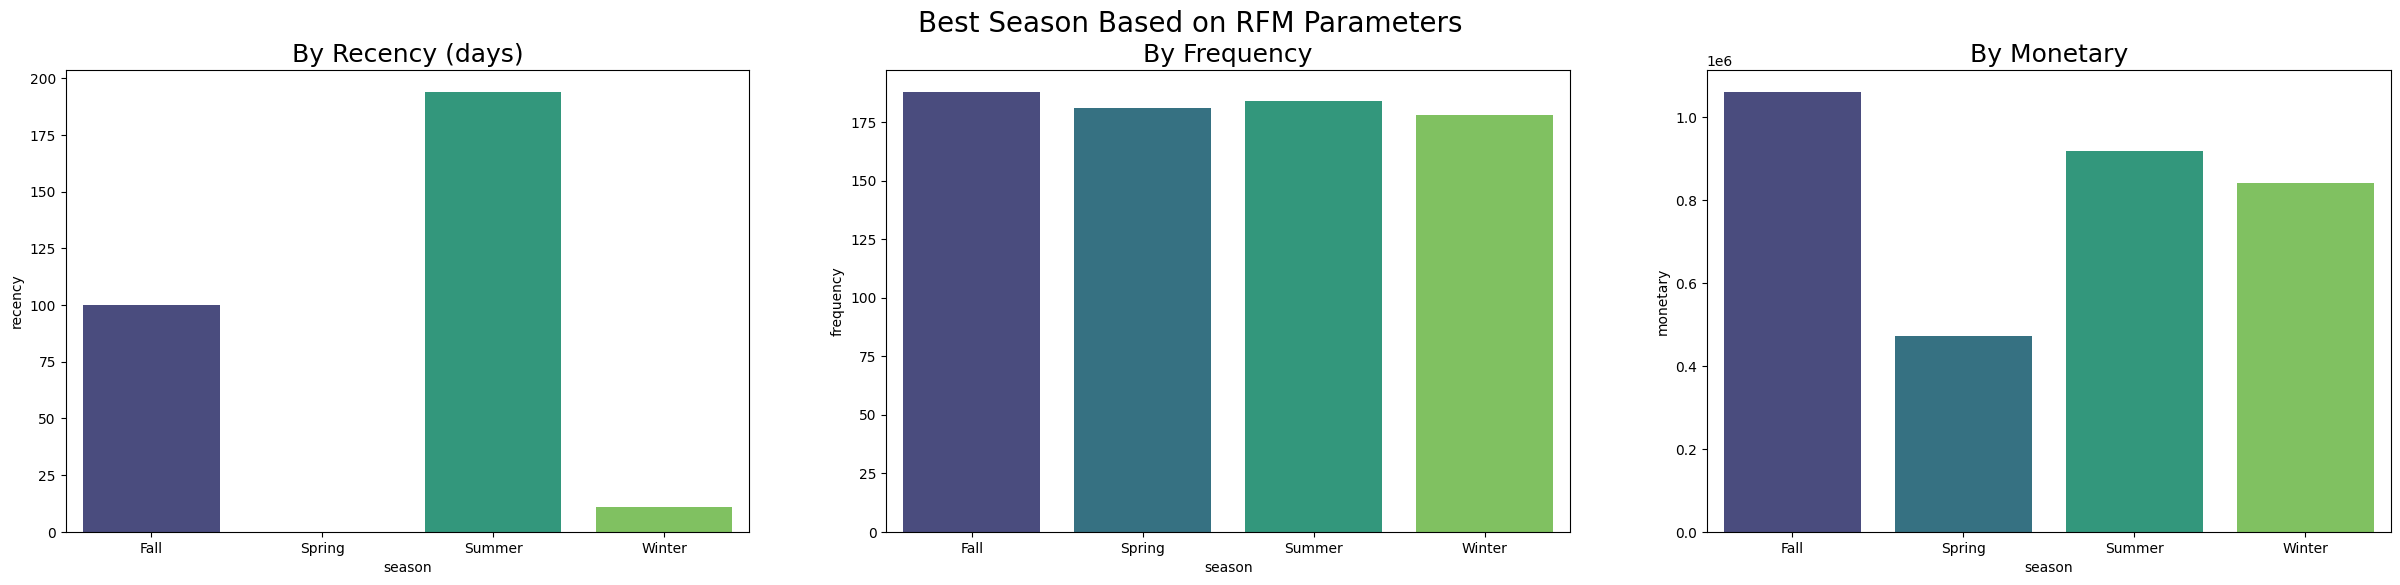

In [10]:
# --- ADVANCED ANALYSIS: RFM ANALYSIS ---
# Menentukan tanggal referensi (asumsi hari ini adalah hari terakhir di dataset)
recent_date = day_df['dteday'].max()

rfm_df = day_df.groupby(by="season", as_index=False).agg({
    "dteday": lambda x: (recent_date - x.max()).days, # Recency
    "instant": "count", # Frequency
    "cnt": "sum" # Monetary
})

rfm_df.columns = ["season", "recency", "frequency", "monetary"]

# Tampilkan hasil RFM
print(rfm_df.head())

# Visualisasi RFM Sederhana
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 6))

sns.barplot(y="recency", x="season", data=rfm_df, palette="viridis", ax=ax[0])
ax[0].set_title("By Recency (days)", fontsize=18)

sns.barplot(y="frequency", x="season", data=rfm_df, palette="viridis", ax=ax[1])
ax[1].set_title("By Frequency", fontsize=18)

sns.barplot(y="monetary", x="season", data=rfm_df, palette="viridis", ax=ax[2])
ax[2].set_title("By Monetary", fontsize=18)

plt.suptitle("Best Season Based on RFM Parameters", fontsize=20)
plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan visualisasi data, musim Fall (Gugur) merupakan musim dengan kontribusi penyewaan tertinggi di tahun 2012, dengan total penyewaan mencapai lebih dari 0.6 juta unit. Hal ini didukung oleh analisis RFM parameter Monetary, di mana musim Fall mencatatkan angka penyewaan akumulatif terbesar dibandingkan musim lainnya. Sebaliknya, musim Spring (Semi) memiliki kontribusi terendah, yang kemungkinan dipengaruhi oleh faktor cuaca yang masih transisi.
- **Conclusion pertanyaan 2:** Terdapat perbedaan pola yang signifikan antara kedua tipe pengguna pada hari kerja. Pengguna Registered menunjukkan pola commuter dengan dua puncak aktivitas utama, yaitu pada jam berangkat kantor (07:00 - 08:00) dan jam pulang kantor (17:00 - 18:00). Sementara itu, pengguna Casual memiliki pola yang lebih landai dan cenderung meningkat di siang hingga sore hari, yang menunjukkan penggunaan sepeda untuk tujuan fleksibel atau rekreasi. Strategi ketersediaan unit sebaiknya difokuskan pada stasiun perkantoran di jam-jam sibuk tersebut.
- ...

**Rekomendasi Action Item:**
- Seasonal Marketing Strategy (Fokus Musim Fall):
Karena musim Fall memiliki Monetary tertinggi, perusahaan harus mengalokasikan anggaran pemasaran terbesar di musim ini.
Tawarkan promo "Paket Langganan Musim Gugur" untuk mengunci loyalitas pengguna sebelum memasuki musim dingin yang performanya menurun (Recency paling tinggi/lama).
- Optimasi Armada pada Jam Sibuk (Commuter Focus):Untuk pengguna Registered, pastikan ketersediaan sepeda di area perkantoran dan stasiun pada pukul 07:00 - 09:00 dan 17:00 - 19:00. Lakukan pemeliharaan rutin (maintenance) sepeda pada jam 10 pagi atau tengah malam agar tidak mengganggu puncak permintaan.
- Incentive Program untuk Pengguna Casual:Pengguna Casual banyak meminjam di siang hari. Berikan notifikasi promo atau diskon khusus "Happy Hour" antara pukul 11:00 - 15:00 pada hari kerja untuk menarik mereka lebih banyak lagi.Sediakan program konversi dari Casual ke Registered (misal: diskon biaya aktivasi) bagi mereka yang sering meminjam di jam tersebut.
- Weather-Based Maintenance (Spring Strategy):Karena musim Spring memiliki angka penyewaan terendah, gunakan periode ini sebagai waktu utama untuk melakukan peremajaan unit (cat ulang, ganti ban, dll) agar saat memasuki musim panas dan gugur, seluruh armada dalam kondisi prima.